In [1]:
from quantum_function import *

# Entanglement of a pair of quantum emitters via continuous fluorescence measurements: a tutorial

### SME - ENTANGLEMENT BY JOINT HOMODYNE DETECTION OF FLUORESCENCE, Chap.5

### Two atoms that emit photons by spontaneous decay, these photons are collected and let them pass through a beam splitter, then we perform homodyne detection

The system is described by Hamiltonian:
$H_{tot} = H_{atom_1} + H_{atom_2} + H_{env} + H_{int}$

where $(\hbar=1)$ $H_{atom_j} = \dfrac{\omega}{2} \cdot \hat{\sigma_{z}}^{j}$

and $H_{int} = \gamma \sum_{j=1}^{2} \left( \hat{a}_{j} \hat{\sigma}_{+}^{j} +\hat{a}^{\dagger}_{j} \hat{\sigma}_{-}^{j}      \right)$

The associated stochastic master equation when performing joint homodyne detection is:

$d \varrho = -i \left[ H_{atoms}, \varrho\right] + \gamma \mathcal{D}\left[\sigma_{-}^{(1)}\right]\varrho+\gamma \mathcal{D}\left[\sigma_{-}^{(2)}\right]\varrho$

In [2]:
#  Convenzione: |e> = (1,0) and |g> = (0,1)

# parameters
GAMMA = 1              # Atom decay rate
OMEGA = 0
T_1 = 1 / GAMMA  # time constant for the decay
#ntraj = 1000 # number of trajectories
I_2 = qeye(2)  # identity operator for 2-level system
sm = sigmam()  # lowering operator for 2-level system (atom)

# operators
sigma_minus_1 = tensor(sm, I_2) # lowering operator for atom 1
sigma_minus_2 = tensor(I_2, sm) # lowering operator for atom 2
sigma_minus_12 = tensor(sigma_minus_1, sigma_minus_2) # combined lowering operator for both atoms  

sigma_minus_list = [sigma_minus_1, sigma_minus_2] # list of lowering operators for both atoms

sigma_plus_1 = sigma_minus_1.dag() # raising operator for atom 1
sigma_plus_2 = sigma_minus_2.dag() # raising operator for atom       
sigma_plus_12 = tensor(sigma_plus_1, sigma_plus_2) # raising operator for both atoms

sigma_plus_list = [sigma_plus_1, sigma_plus_2] # list of raising operators for both atoms

H_free_atom_1 = 0.5 * OMEGA * tensor(sigmaz(), I_2) # Free Hamiltonian atom 1
H_free_atom_2 = 0.5 * OMEGA * tensor(I_2, sigmaz()) # Free Hamiltonian atom 2
H_free = H_free_atom_1 + H_free_atom_2 # Free Hamiltonian for both atoms        

ee = tensor(basis(2, 0), basis(2, 0))# initial vector state, |e, e> (the atoms must decay from the excited state!)
times = np.arange(0, 5*T_1, 0.001*T_1) # time vector

## Joint heterodyne
$d \varrho = -i \left[ H_{atoms}, \varrho\right] + \gamma \mathcal{D}\left[\sigma_{-}^{(1)}\right]\varrho+\gamma \mathcal{D}\left[\sigma_{-}^{(2)}\right]\varrho = -i \left[ H, \varrho\right] + \gamma \mathcal{D}\left[ \dfrac{\sigma_{-}^{(1)}+\sigma_{-}^{(2)}}{\sqrt{2}}\right]\varrho+\gamma \mathcal{D}\left[ \dfrac{\sigma_{-}^{(1)}-\sigma_{-}^{(2)}}{\sqrt{2}}\right]\varrho$

In [5]:
def concurrence_for_solver_general(t, state):

    if state.isket:
        conc = concurrence_pure_state(state)

    else:
        sysy = tensor(sigmay(), sigmay())

        rho_tilde = (state * sysy) * (state.conj() * sysy)

        evals = rho_tilde.eigenenergies()

        # abs to avoid problems with sqrt for very small negative numbers
        evals = abs(np.sort(np.real(evals)))

        sqrt_evals = np.sqrt(evals)
        lsum = sqrt_evals[3] - sqrt_evals[2] - sqrt_evals[1] - sqrt_evals[0]
        conc = np.maximum(0, lsum)

    return conc

In [10]:
my_theta = [0, 1 / (3), 1 /2] # angles for the homodyne detection
ntraj = 10

mean_conc_ee_solutions_jhom = []

for theta in my_theta:
    sc_ops = [
    np.sqrt(GAMMA / 2) * (sigma_minus_1 + sigma_minus_2),
    np.exp(1j * np.pi * theta) * np.sqrt(GAMMA / 2) * (sigma_minus_1 - sigma_minus_2)
    ]
   
    my_exp = ssesolve(
        H_free, ee, times,
        sc_ops=sc_ops,
        ntraj=ntraj,
        heterodyne = True,
        e_ops=[concurrence_for_solver_general],
        options={"dt": 0.001, "num_cpus": 4, "map" : "parallel"},
    )

    mean_conc = my_exp.expect[0]

    mean_conc_ee_solutions_jhom.append(mean_conc)

10.0%. Run time:  32.47s. Est. time left: 00:00:04:52
20.0%. Run time:  32.49s. Est. time left: 00:00:02:09
30.0%. Run time:  32.49s. Est. time left: 00:00:01:15
40.0%. Run time:  32.49s. Est. time left: 00:00:00:48
Total run time:  32.50s


BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.

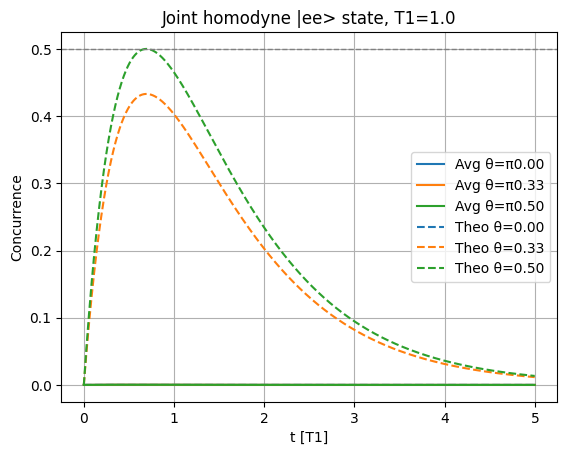

In [9]:
line_theta = []
line_theo = []

for i, theta in enumerate(my_theta):
    # plottiamo la curva per il theta i-esimo
    line_theta_temp, = plt.plot(times, mean_conc_ee_solutions_jhom[i], label=f"Avg θ=π{(theta):.2f}")
    line_theta.append(line_theta_temp)

    line_theor_temp, = plt.plot(times, theo_concurrence(times, GAMMA)*np.sin(np.pi*theta), color=line_theta_temp.get_color(), linestyle ='--', label=f"Theo θ={theta:.2f}")
    line_theo.append(line_theor_temp)

#line2, = plt.plot(times, conc_ee_solutions_jhom[11], label="Trajectory #10")
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='y = 0.5')
#plt.axhline(y=1, color='red', linestyle='-', linewidth=1.5, label='y = 1')

plt.xlabel("t [T1]")
plt.ylabel("Concurrence")
plt.title(f"Joint homodyne |ee> state, T1={T_1}")
plt.grid(True)
plt.legend(handles = line_theta + line_theo)
plt.show()



In [15]:
from qutip import parallel_map

def test_func(x):
    return x**2
if __name__ == "__main__":
    out = parallel_map(test_func, [1,2,3], task_kwargs={}, map_kw={'num_cpus': 1})
    print(out)


BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.